<h1>
  <span class="prefix"></span>
  <span class="headline">Data Science Fundamentals - Lab - Titanic EDA</span>
</h1>

## About
For this lab, we're going to take a look at the Titanic manifest. We'll be exploring this data to see what we can learn regarding the survival rates of different groups of people.

## Submission
Lab submissions should be made as per guidance from your instructor. Your submission will be in the form of a link to your Github fork of this repository.

## Prework
Sync your fork to the repo.


---

## Important note
Please ignore the `_layouts` folder and the `config.yml` file in the root of this repo.  They are needed to make sure the repo renders well; please don't change them or delete them and your repo will work fine :)


## Step 1: Reading the data

In the [notebook](./lab-eda-titanic-student-submission.ipynb) provided, do the following:

1. Import `pandas` and `matplotlib.pyplot`
1. Load [train.csv](./train.csv) as a `pandas` DataFrame.
1. In each of the following sections, copy the question as a python comment, then answer the question with your own code.
1. Refer to the [Titanic Kaggle competition](https://www.kaggle.com/c/titanic/data) if you need an explanation for any of the columns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

titanic = pd.read_csv('https://raw.githubusercontent.com/markokct/DSB-Unit-02-EDA-with-Pandas/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv')

titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic.shape

(891, 12)

In [4]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
titanic["Survived"].mean() # survival rate

np.float64(0.3838383838383838)

## Step 2: Cleaning the data

**1. Create a bar chart showing how many missing values are in each column**
  - *Bonus* : Theres a good library for visualizing missing values called Missingno.
      - [Install Instructions](https://pypi.org/project/missingno/)
      - [Usage Documentation](https://github.com/ResidentMario/missingno)


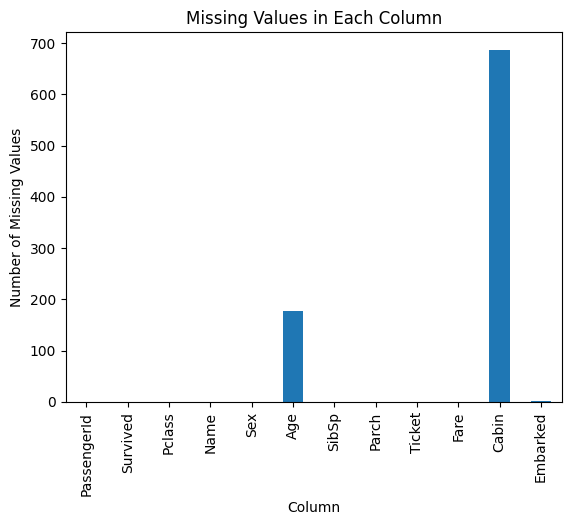

In [6]:
missing_values = titanic.isna().sum()
missing_values.plot(kind='bar')

plt.title("Missing Values in Each Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.show()

**2. Which column has the most `NaN` values? How many cells in that column are empty?**

In [7]:
column_with_most_missing_values = missing_values.idxmax()
number_of_missing = missing_values.max()

print(f"Column with the most missing values: {column_with_most_missing_values}")
print(f"Number of missing values: {number_of_missing}")

Column with the most missing values: Cabin
Number of missing values: 687


**3. Delete all rows where `Embarked` is empty**

In [8]:
titanic = titanic.dropna(subset=["Embarked"])

print("Missing Embarked values:", titanic["Embarked"].isna().sum())
print("Number of rows:", len(titanic))

Missing Embarked values: 0
Number of rows: 889


4. Fill all empty cabins with **¯\\_(ツ)_**
Note: `NaN`, empty, and missing are synonymous.

In [9]:
titanic["Cabin"] = titanic["Cabin"].fillna(r"¯\(ツ)/¯")

print("Missing Cabin values", titanic["Cabin"].isna().sum())

Missing Cabin values 0


## Step 3: Feature extraction
1.  There are two columns that pertain to how many family members are on the boat for a given person. Create a new column called `FamilyCount` which will be the sum of those two columns.


In [10]:
titanic["FamilyCount"] = titanic["SibSp"] + titanic["Parch"]

2. Reverends have a special title in their name. Create a column called `IsReverend`: 1 if they're a preacher, 0 if they're not.


In [11]:
titanic["IsReverend"] = titanic["Name"].str.contains("Rev.", regex=False).astype(int)

titanic[titanic["IsReverend"] == 1][["Name", "IsReverend"]]

,Name,IsReverend
149,"Byles, Rev. Thomas Roussel Davids",1
150,"Bateman, Rev. Robert James",1
249,"Carter, Rev. Ernest Courtenay",1
626,"Kirkland, Rev. Charles Leonard",1
848,"Harper, Rev. John",1
886,"Montvila, Rev. Juozas",1


3. In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using `pd.get_dummies`
  - Familiarize yourself with the [`pd.get_dummies` documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)
  - Create 3 columns: `Embarked_C`, `Embarked_Q` and `Embarked_S`. These columns will have 1's and 0's that correspond to the `C`, `Q` and `S` values in the `Embarked` column
  - Do the same thing for `Sex`
  - BONUS: Extract the title from everyone's name and create dummy columns

In [12]:
embarked_dummies = pd.get_dummies(
    titanic["Embarked"],
    prefix="Embarked",
    dtype=int
)

titanic = pd.concat(
    [titanic, embarked_dummies],
    axis=1
)

titanic[["Embarked", "Embarked_C", "Embarked_Q", "Embarked_S"]].head(10)

,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,S,0,0,1
1,C,1,0,0
2,S,0,0,1
3,S,0,0,1
4,S,0,0,1
5,Q,0,1,0
6,S,0,0,1
7,S,0,0,1
8,S,0,0,1
9,C,1,0,0


In [13]:
# Create Sex dummies columns

sex_dummies = pd.get_dummies(
    titanic["Sex"],
    prefix="Sex",
    dtype=int
)

titanic = pd.concat(
    [titanic, sex_dummies],
    axis=1
)

titanic[["Sex", "Sex_female", "Sex_male"]].head()

,Sex,Sex_female,Sex_male
0,male,0,1
1,female,1,0
2,female,1,0
3,female,1,0
4,male,0,1


In [14]:
# Bonus

titanic["title"] = titanic["Name"].str.extract(r"([A-Za-z]+)\.")
titanic[["Name", "title"]].head(20)

,Name,title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


## Step 4: Exploratory analysis
_[`df.groupby()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html) may be very useful._

1. What was the survival rate overall?
2. Which gender fared the worst? What was their survival rate?
3. What was the survival rate for each `Pclass`?
4. Did any reverends survive? How many?
5. What is the survival rate for cabins marked **¯\\_(ツ)_/¯**
6. What is the survival rate for people whose `Age` is empty?
7. What is the survival rate for each port of embarkation?
8. What is the survival rate for children (under 12) in each `Pclass`?
9. Did the captain of the ship survive? Is he on the list?
10. Of all the people that died, who had the most expensive ticket? How much did it cost?
11. Does having family on the boat help or hurt your chances of survival?

In [15]:
# 1. What was the survival rate overall?

overall_survival_rate = titanic['Survived'].mean()

print(f"Overall survival rate: {overall_survival_rate:.2%}")

Overall survival rate: 38.25%


In [16]:
# 2. Which gender fared the worst? What was their survival rate?

survival_by_sex = titanic.groupby('Sex')['Survived'].mean()

print(survival_by_sex)

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64


In [17]:
# 3. What was the survival rate for each Pclass?

survival_by_class = titanic.groupby('Pclass')['Survived'].mean()

print(survival_by_class)

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [18]:
# 4. Did any reverends survive? How many?

reverends = titanic[titanic['IsReverend'] == 1]

reverend_survivors = reverends['Survived'].sum()

print("Number of reverends:", len(reverends))
print("Reverends who survived:", reverend_survivors)

Number of reverends: 6
Reverends who survived: 0


In [19]:
# 5. What is the survival rate for cabins marked ¯\_(ツ)_/¯

unknown_cabins = titanic[
    titanic['Cabin'] == r'¯\_(ツ)_/¯'
]

unknown_cabin_survival = unknown_cabins['Survived'].mean()

print(f"Survival rate: {unknown_cabin_survival:.2%}")

Survival rate: nan%


In [20]:
# 6. What is the survival rate for people whose Age is empty?

missing_age = titanic[titanic['Age'].isna()]

missing_age_survival = missing_age['Survived'].mean()

print(f"Survival rate: {missing_age_survival:.2%}")

Survival rate: 29.38%


In [21]:
# 7. What is the survival rate for each port of embarkation?

survival_by_port = titanic.groupby('Embarked')['Survived'].mean()

print(survival_by_port)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [22]:
# 8. What is the survival rate for children under 12 in each Pclass?

children = titanic[titanic['Age'] < 12]

child_survival_by_class = children.groupby('Pclass')['Survived'].mean()

print(child_survival_by_class)

Pclass
1    0.750000
2    1.000000
3    0.404255
Name: Survived, dtype: float64


In [23]:
# 9. Did the captain of the ship survive? Is he on the list?

titanic[
    titanic['Name'].str.contains('Capt.', regex=False, na=False)
][['Name', 'Survived']]

,Name,Survived
745,"Crosby, Capt. Edward Gifford",0


In [24]:
# 10. Of all the people that died, who had the most expensive ticket?
# How much did it cost?

died = titanic[titanic['Survived'] == 0]

highest_fare = died['Fare'].max()

most_expensive_died = died[
    died['Fare'] == highest_fare
]

print(
    most_expensive_died[['Name', 'Fare']]
)

                               Name   Fare
27   Fortune, Mr. Charles Alexander  263.0
438               Fortune, Mr. Mark  263.0


In [25]:
# 11. Does having family on the boat help or hurt your chances of survival?

titanic['HasFamily'] = (
    titanic['FamilyCount'] > 0
).astype(int)

family_survival = titanic.groupby('HasFamily')['Survived'].mean()

print(family_survival)

HasFamily
0    0.300935
1    0.505650
Name: Survived, dtype: float64






## Step 5: Plotting
Using `matplotlib` and `seaborn`, create several charts showing the survival rates of different groups of people. It's fine if a handful of charts are basic (Gender, Age, etc), but what we're really looking for is something beneath the surface.


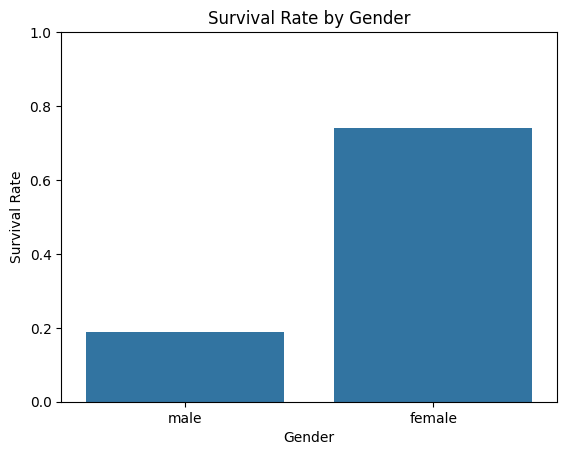

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Survival rate by gender

sns.barplot(
    data=titanic,
    x='Sex',
    y='Survived',
    errorbar=None
)

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

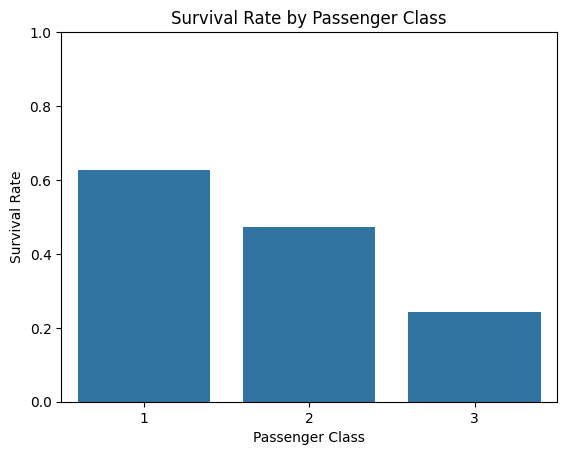

In [27]:
# Survival rate by passenger class

sns.barplot(
    data=titanic,
    x='Pclass',
    y='Survived',
    errorbar=None
)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

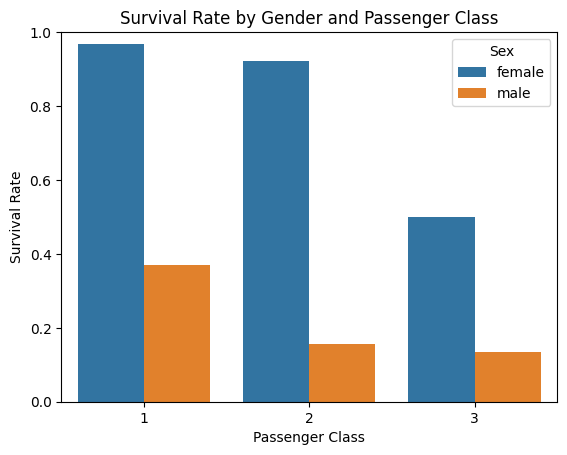

In [28]:
# Survival rate by gender and passenger class

sns.barplot(
    data=titanic,
    x='Pclass',
    y='Survived',
    hue='Sex',
    errorbar=None
)

plt.title('Survival Rate by Gender and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

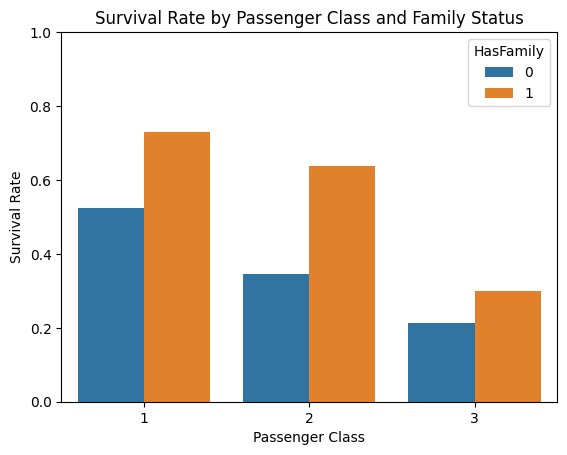

In [30]:
# Survival rate by family status and passenger class

sns.barplot(
    data=titanic,
    x='Pclass',
    y='Survived',
    hue='HasFamily',
    errorbar=None
)

plt.title('Survival Rate by Passenger Class and Family Status')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

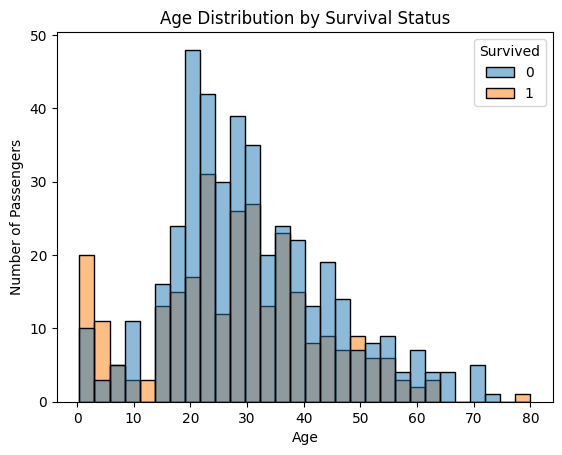

In [31]:
# Age distribution by survival status

sns.histplot(
    data=titanic,
    x='Age',
    hue='Survived',
    multiple='layer',
    bins=30,
    alpha=0.5
)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()